Connect to dataset on google drive if you want to run notebook on google colab

In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#import all required libraries and constants
import dlib
import cv2
import os
import re
import json
from pylab import *
from PIL import Image, ImageChops, ImageEnhance
import scipy
import scipy.misc
from scipy import ndimage
import skimage.io
import skimage.filters
import sys
import tensorflow as tf
import cv2
import os
import numpy as np
from PIL import Image, ImageChops, ImageEnhance
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import librosa
import librosa.display
import seaborn as sns
SAMPLE_RATE = 22050  # Sample rate of your audio files
DURATION = 5  # Duration of audio clips in seconds
max_time_steps = 109  # Define the maximum time steps for your model
N_MFCC = 13  # You can adjust this value based on your needs

We conducted four distinct evaluations on the test set, employing two models for visual deepfake detection and two models for audio deepfake detection. The visual models include one based on Xception and another based on DenseNet, while the audio models utilize MFCC and mel spectrogram preprocessing techniques. The evaluations encompass the following scenarios:

Audio evaluation using MFCC with visual frame evaluation using Xception.

Audio evaluation using MFCC with visual frame evaluation using DenseNet.

Audio evaluation using mel spectrogram with visual frame evaluation using Xception.

Audio evaluation using mel spectrogram with visual frame evaluation using DenseNet.

In [ ]:
# load Xception-based model and MFCC-utilized model
visual_model = load_model('/content/drive/MyDrive/epochs_50_layers__32__30_aug_model.h5')
audio_model = load_model('/content/drive/MyDrive/mfcc_audio_model.h5')

In [ ]:
import seaborn as sns
from PIL import Image
# Function to test a video and return the predicted class
def test_video(video_path,main_path):
    fake_prob = 0
    real_prob = 0
    fake_prob_frames = 0
    real_prob_frames = 0
    i = 0
    while True:
      frame_path = main_path + os.path.basename(video_path).split('.')[0] + '_' + str(i) + '.png'
      if os.path.exists(frame_path):
          # Load the image
          # Load the image using PIL
          img = Image.open(frame_path)

          # Convert the PIL Image to a NumPy array
          img_array = img_to_array(img)

          # Resize the image using OpenCV
          resized_img_array = cv2.resize(img_array, (128, 128))

          # Flatten and normalize data
          data = resized_img_array.flatten() / 255.0
          data = data.reshape(-1, 128, 128, 3)
          # Apply a threshold to convert probabilities into binary predictions
          threshold = 0.5
          y_pred = (visual_model.predict(data) > threshold).astype(int)
          if y_pred==1:
            real_prob_frames+=1
          else:
            fake_prob_frames+=1
          i+=1
      else:
          # frames finished, then break loop
          break
    if fake_prob_frames > real_prob_frames: #thershold
      fake_prob_frames = 0
      real_prob_frames = 0
      return 0
    else:
      fake_prob_frames = 0
      real_prob_frames = 0
      return 1


In [ ]:
# Function to extract MFCC features
def extract_mfcc(audio, sample_rate, n_mfcc=13):
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
    return mfccs

The dataset comprises four distinct classes represented by folders: RARV, FARV, RAFV, and FAFV.  Initially, we assess the accuracy of each individual class and subsequently calculate the overall accuracy.

Video is fake if either visual or audio model results fake.

In [ ]:
# Set the path to the directory you want to loop through
directory_path = '/content/drive/MyDrive/RARV_test_moved'
audio_directory_path = '/content/drive/MyDrive/RARV_audio_test'
# List files in the directory
files = os.listdir(directory_path)
video_fakeness = 0 # counter for videos will be detected fake
total_fake_predictions_in_RARV = 0
total_real_predictions_in_RARV = 0
total_videos_in_RARV = 0
# Loop through the files
for video_file in files:
    video_name = os.path.splitext(video_file)[0]  # Get the name without the extension
    audio_file = f"{video_name}.flac"  # Create the corresponding audio file name
    video_file_path = os.path.join(directory_path, video_file)
    audio_file_path = os.path.join(audio_directory_path, audio_file)

    predicted_class = test_video(video_file_path,'/content/drive/MyDrive/frames_RARV_test/')
    print(predicted_class)

    if(predicted_class==0):
      print("visual video is fake")
      video_fakeness+=1
    else:
      print("visual video is real")
    TEST_FILE=audio_file_path
    # Load and preprocess test data using librosa
    X_test = []

    try:
        # Load audio file using librosa
        audio, _ = librosa.load(audio_file_path, sr=SAMPLE_RATE, duration=DURATION)

        # Extract MFCC features using custom function
        mfcc_features = extract_mfcc(audio, SAMPLE_RATE, n_mfcc=N_MFCC)

        # Ensure all MFCC features have the same width (time steps)
        if mfcc_features.shape[1] < max_time_steps:
            mfcc_features = np.pad(mfcc_features, ((0, 0), (0, max_time_steps - mfcc_features.shape[1])), mode='constant')
        else:
            mfcc_features = mfcc_features[:, :max_time_steps]

        X_test.append(mfcc_features)

        # Convert list to numpy array
        X_test = np.array(X_test)
        # Predict using the loaded model
        y_pred = audio_model.predict(X_test)

        # Apply a threshold to convert probabilities into binary predictions
        threshold = 0.5
        y_pred = (y_pred > threshold).astype(int)
        if y_pred > 0.5:
            print("audio real")
        else:
            print("audio fake")
            video_fakeness += 1
    except FileNotFoundError:
        # silet video has no audio, so we predict fakeness based on visual only
        print(f"Audio file not found: {TEST_FILE}")

    if video_fakeness > 0:
        total_fake_predictions_in_RARV += 1
        print("video is fake")
    else:
        print("video is real")
    video_fakeness = 0 #reset fakeness counter to zero  #reset fakeness counter to zero
    total_videos_in_RARV += 1

total_real_predictions_in_RARV = total_videos_in_RARV - total_fake_predictions_in_RARV


1/1 [==============================] - 0s 107ms/step
1
visual video is real
1/1 [==============================] - 0s 36ms/step
audio real
video is real
1/1 [==============================] - 0s 115ms/step
1
visual video is real
1/1 [==============================] - 0s 34ms/step
audio real
video is real
1/1 [==============================] - 0s 113ms/step
1
visual video is real
1/1 [==============================] - 0s 37ms/step
audio real
video is real
1/1 [==============================] - 0s 100ms/step
1
visual video is real
1/1 [==============================] - 0s 37ms/step
audio real
video is real
1/1 [==============================] - 0s 120ms/step
1
visual video is real
1/1 [==============================] - 0s 36ms/step
audio real
video is real
1/1 [==============================] - 0s 110ms/step
1
visual video is real
1/1 [==============================] - 0s 42ms/step
audio real
video is real
1/1 [==============================] - 0s 98ms/step
1
visual video is real
1/1 [==

In [ ]:
# Set the path to the directory you want to loop through
directory_path = '/content/drive/MyDrive/FARV_test_moved'
audio_directory_path = '/content/drive/MyDrive/FARV_audio_test'
# List files in the directory
files = os.listdir(directory_path)
video_fakeness = 0 # counter for videos will be detected fake
total_fake_predictions_in_FARV = 0
total_videos_in_FARV = 0
# Loop through the files
for video_file in files:
    video_name = os.path.splitext(video_file)[0]  # Get the name without the extension
    audio_file = f"{video_name}.flac"  # Create the corresponding audio file name
    video_file_path = os.path.join(directory_path, video_file)
    audio_file_path = os.path.join(audio_directory_path, audio_file)

    predicted_class = test_video(video_file_path,'/content/drive/MyDrive/frames_FARV_test/')
    print(predicted_class)
    if(predicted_class==0):
      print("visual video is fake")
      video_fakeness+=1
    else:
      print("visual video is real")
    TEST_FILE=audio_file_path
    # Load and preprocess test data using librosa
    X_test = []

    try:
        # Load audio file using librosa
        audio, _ = librosa.load(audio_file_path, sr=SAMPLE_RATE, duration=DURATION)

        # Extract MFCC features using custom function
        mfcc_features = extract_mfcc(audio, SAMPLE_RATE, n_mfcc=N_MFCC)

        # Ensure all MFCC features have the same width (time steps)
        if mfcc_features.shape[1] < max_time_steps:
            mfcc_features = np.pad(mfcc_features, ((0, 0), (0, max_time_steps - mfcc_features.shape[1])), mode='constant')
        else:
            mfcc_features = mfcc_features[:, :max_time_steps]

        X_test.append(mfcc_features)

        # Convert list to numpy array
        X_test = np.array(X_test)
        # Predict using the loaded model
        y_pred = audio_model.predict(X_test)

        # Apply a threshold to convert probabilities into binary predictions
        threshold = 0.5
        y_pred = (y_pred > threshold).astype(int)
        if y_pred > 0.5:
            print("audio real")
        else:
            print("audio fake")
            video_fakeness += 1

    except FileNotFoundError:
        # silet video has no audio, so we predict fakeness based on visual only
        print(f"Audio file not found: {TEST_FILE}")

    if video_fakeness > 0:
        total_fake_predictions_in_FARV += 1
        print("video is fake")
    else:
        print("video is real")
    video_fakeness = 0 #reset fakeness counter to zero
    total_videos_in_FARV += 1

total_real_predictions_in_FARV = total_videos_in_FARV - total_fake_predictions_in_FARV


1/1 [==============================] - 0s 118ms/step
1
visual video is real
1/1 [==============================] - 0s 35ms/step
audio fake
video is fake
1/1 [==============================] - 0s 106ms/step
1
visual video is real
1/1 [==============================] - 0s 34ms/step
audio fake
video is fake
1/1 [==============================] - 0s 97ms/step
1
visual video is real
1/1 [==============================] - 0s 40ms/step
audio fake
video is fake
1/1 [==============================] - 0s 97ms/step
1
visual video is real
1/1 [==============================] - 0s 38ms/step
audio fake
video is fake
1/1 [==============================] - 0s 96ms/step
1
visual video is real
1/1 [==============================] - 0s 43ms/step
audio fake
video is fake
1/1 [==============================] - 0s 160ms/step
1
visual video is real
1/1 [==============================] - 0s 43ms/step
audio fake
video is fake
1/1 [==============================] - 0s 171ms/step
1
visual video is real
1/1 [====

In [ ]:
# Set the path to the directory you want to loop through
directory_path = '/content/drive/MyDrive/FAFV_test_moved'
audio_directory_path = '/content/drive/MyDrive/FAFV_audio_test'
# List files in the directory
files = os.listdir(directory_path)
video_fakeness = 0 # counter for videos will be detected fake
total_fake_predictions_in_FAFV = 0
total_videos_in_FAFV = 0

# Loop through the files
for video_file in files:
    video_name = os.path.splitext(video_file)[0]  # Get the name without the extension
    audio_file = f"{video_name}.flac"  # Create the corresponding audio file name
    video_file_path = os.path.join(directory_path, video_file)
    audio_file_path = os.path.join(audio_directory_path, audio_file)

    predicted_class = test_video(video_file_path,'/content/drive/MyDrive/frames_FAFV_test/')
    print(predicted_class)
    if predicted_class == 0:
        print("visual video is fake")
        video_fakeness += 1
    else:
        print("visual video is real")
    TEST_FILE = audio_file_path
    # Load and preprocess test data using librosa
    X_test = []

    try:
        # Load audio file using librosa
        audio, _ = librosa.load(audio_file_path, sr=SAMPLE_RATE, duration=DURATION)

        # Extract MFCC features using custom function
        mfcc_features = extract_mfcc(audio, SAMPLE_RATE, n_mfcc=N_MFCC)

        # Ensure all MFCC features have the same width (time steps)
        if mfcc_features.shape[1] < max_time_steps:
            mfcc_features = np.pad(mfcc_features, ((0, 0), (0, max_time_steps - mfcc_features.shape[1])), mode='constant')
        else:
            mfcc_features = mfcc_features[:, :max_time_steps]

        X_test.append(mfcc_features)

        # Convert list to numpy array
        X_test = np.array(X_test)
        # Predict using the loaded model
        y_pred = audio_model.predict(X_test)

        # Apply a threshold to convert probabilities into binary predictions
        threshold = 0.5
        y_pred = (y_pred > threshold).astype(int)
        if y_pred > 0.5:
            print("audio real")
        else:
            print("audio fake")
            video_fakeness += 1

    except FileNotFoundError:
        # silet video has no audio, so we predict fakeness based on visual only
        print(f"Audio file not found: {TEST_FILE}")

    if video_fakeness > 0:
        total_fake_predictions_in_FAFV += 1
        print("video is fake")
    else:
        print("video is real")
    video_fakeness = 0 #reset fakeness counter to zero
    total_videos_in_FAFV += 1

total_real_predictions_in_FAFV = total_videos_in_FAFV - total_fake_predictions_in_FAFV


Streaming output truncated to the last 5000 lines.
1/1 [==============================] - 0s 101ms/step
0
visual video is fake
1/1 [==============================] - 0s 30ms/step
audio fake
video is fake
1/1 [==============================] - 0s 106ms/step
0
visual video is fake
1/1 [==============================] - 0s 27ms/step
audio fake
video is fake
1/1 [==============================] - 0s 97ms/step
0
visual video is fake
1/1 [==============================] - 0s 41ms/step
audio fake
video is fake
1/1 [==============================] - 0s 152ms/step
0
visual video is fake
1/1 [==============================] - 0s 51ms/step
audio fake
video is fake
1/1 [==============================] - 0s 97ms/step
0
visual video is fake
1/1 [==============================] - 0s 33ms/step
audio fake
video is fake
1/1 [==============================] - 0s 105ms/step
0
visual video is fake
1/1 [==============================] - 0s 33ms/step
audio fake
video is fake
1/1 [============================

In [ ]:
import os
# Set the path to the directory you want to loop through
directory_path = '/content/drive/MyDrive/RAFV_test_moved'
audio_directory_path = '/content/drive/MyDrive/RAFV_audio_test'
# List files in the directory
files = os.listdir(directory_path)
video_fakeness = 0 # counter for videos will be detected fake
total_fake_predictions_in_RAFV = 0
total_videos_in_RAFV = 0

# Loop through the files
for video_file in files:
    video_name = os.path.splitext(video_file)[0]  # Get the name without the extension
    audio_file = f"{video_name}.flac"  # Create the corresponding audio file name
    video_file_path = os.path.join(directory_path, video_file)
    audio_file_path = os.path.join(audio_directory_path, audio_file)

    predicted_class = test_video(video_file_path,'/content/drive/MyDrive/frames_RAFV_test/')
    print(predicted_class)
    if predicted_class == 0:
        print("visual video is fake")
        video_fakeness += 1
    else:
        print("visual video is real")
    TEST_FILE = audio_file_path

    # Load and preprocess test data using librosa
    X_test = []

    try:
        # Load audio file using librosa
        audio, _ = librosa.load(audio_file_path, sr=SAMPLE_RATE, duration=DURATION)

        # Extract MFCC features using custom function
        mfcc_features = extract_mfcc(audio, SAMPLE_RATE, n_mfcc=N_MFCC)

        # Ensure all MFCC features have the same width (time steps)
        if mfcc_features.shape[1] < max_time_steps:
            mfcc_features = np.pad(mfcc_features, ((0, 0), (0, max_time_steps - mfcc_features.shape[1])), mode='constant')
        else:
            mfcc_features = mfcc_features[:, :max_time_steps]

        X_test.append(mfcc_features)

        # Convert list to numpy array
        X_test = np.array(X_test)
        # Predict using the loaded model
        y_pred = audio_model.predict(X_test)

        # Apply a threshold to convert probabilities into binary predictions
        threshold = 0.5
        y_pred = (y_pred > threshold).astype(int)
        if y_pred > 0.5:
            print("audio real")
        else:
            print("audio fake")
            video_fakeness += 1

    except FileNotFoundError:
        # silet video has no audio, so we predict fakeness based on visual only
        print(f"Audio file not found: {TEST_FILE}")

    if video_fakeness > 0:
        total_fake_predictions_in_RAFV += 1
        print("video is fake")
    else:
        print("video is real")
    video_fakeness = 0 #reset fakeness counter to zero
    total_videos_in_RAFV += 1

total_real_predictions_in_RAFV = total_videos_in_RAFV - total_fake_predictions_in_RAFV


Streaming output truncated to the last 5000 lines.
video is fake
1/1 [==============================] - 0s 99ms/step
0
visual video is fake
1/1 [==============================] - 0s 35ms/step
audio real
video is fake
1/1 [==============================] - 0s 102ms/step
0
visual video is fake
1/1 [==============================] - 0s 33ms/step
audio real
video is fake
1/1 [==============================] - 0s 102ms/step
0
visual video is fake
1/1 [==============================] - 0s 35ms/step
audio real
video is fake
1/1 [==============================] - 0s 111ms/step
0
visual video is fake
1/1 [==============================] - 0s 34ms/step
audio real
video is fake
1/1 [==============================] - 0s 105ms/step
0
visual video is fake
1/1 [==============================] - 0s 33ms/step
audio real
video is fake
1/1 [==============================] - 0s 102ms/step
0
visual video is fake
1/1 [==============================] - 0s 35ms/step
audio real
video is fake
1/1 [=============

After evaluating the accuracy of all 4 folders, we now calculate the total accuracy

As usual, total accuracy = (true positive + true negative) / (total poistive + total negative)
here in our approach :   
real videos represent true and fake videos represent false. Then,

true positive is total_real_predictions_in_RARV

true negative is total_fake_predictions_in_FARV + total_fake_predictions_in_RAFV + total_fake_predictions_in_FAFV

total positive is total_videos_in_RARV

total negative is total_videos_in_FARV + total_videos_in_RAFV + total_videos_in_FAFV


In [ ]:
total_accuracy = (total_real_predictions_in_RARV+total_fake_predictions_in_FARV+total_fake_predictions_in_RAFV+total_fake_predictions_in_FAFV) / (total_videos_in_RARV+total_videos_in_FARV+total_videos_in_RAFV+total_videos_in_FAFV)
print(total_accuracy)

0.9855376720317


Now we decalre y_test (ground truth) and y_pred

y_test is array of total real videos and total fake videos,

y_pred is array of real and fake predictions to the corresponding videos in y_test

In [ ]:
y_test = np.concatenate([np.ones(100), np.zeros(4187)])

real_pred = np.concatenate([np.ones(95), np.zeros(5)])
fake_pred = np.concatenate([np.ones(57), np.zeros(4130)])

# Merge the arrays
y_pred = np.concatenate([real_pred, fake_pred])

print(y_test)
print(y_pred)

[1. 1. 1. ... 0. 0. 0.]
[1. 1. 1. ... 0. 0. 0.]


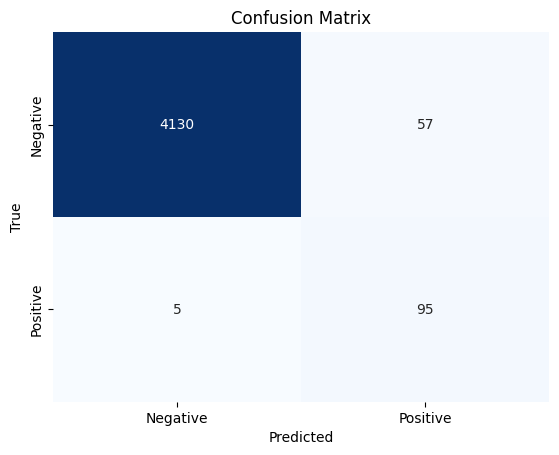

In [ ]:
from sklearn.metrics import confusion_matrix
# Create the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

#4287

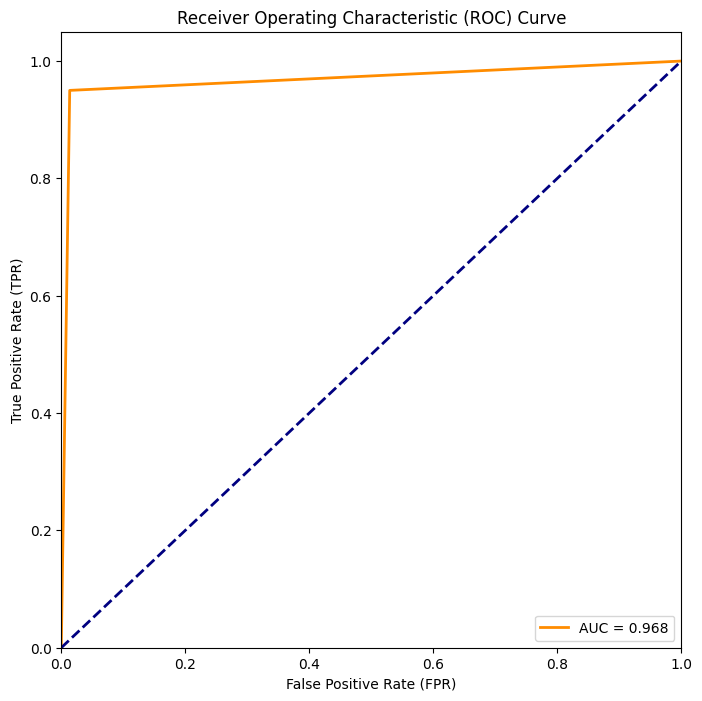

In [ ]:
from sklearn.metrics import roc_curve, auc
# Compute ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred)

# Compute area under the curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()